In [36]:
#Import des librairies 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Chargement du dataset
df = pd.read_csv(r'C:\Users\lenovo\Desktop\ecommerce_sales/ecommerce_customer_behavior_dataset.csv')

# Conversion du type de la date en datetime
df['Date'] = pd.to_datetime(df['Date'])

# Affichage des infos basiques
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (5000, 18)

First few rows:


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [3]:
df.info


<bound method DataFrame.info of         Order_ID Customer_ID       Date  Age  Gender      City  \
0     ORD_001337  CUST_01337 2023-01-01   27  Female     Bursa   
1     ORD_004885  CUST_04885 2023-01-01   42    Male     Konya   
2     ORD_004507  CUST_04507 2023-01-01   43  Female    Ankara   
3     ORD_000645  CUST_00645 2023-01-01   32    Male  Istanbul   
4     ORD_000690  CUST_00690 2023-01-01   40  Female  Istanbul   
...          ...         ...        ...  ...     ...       ...   
4995  ORD_001048  CUST_01048 2024-03-26   18  Female     Izmir   
4996  ORD_001051  CUST_01051 2024-03-26   27    Male     Adana   
4997  ORD_003543  CUST_03543 2024-03-26   45  Female   Antalya   
4998  ORD_004443  CUST_04443 2024-03-26   41  Female  Istanbul   
4999  ORD_000902  CUST_00902 2024-03-26   30  Female     Konya   

     Product_Category  Unit_Price  Quantity  Discount_Amount  Total_Amount  \
0                Toys       54.28         1             0.00         54.28   
1                To

In [32]:
# Dataset info
print("Dataset Information:")
df.dtypes

print("\n" + "="*50)
print("Valeurs manquantes:")
print(df.isnull().sum())


Dataset Information:

Valeurs manquantes:
Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
Tranche_Age                 0
Tranche_Session             2
Bonne_Note                  0
dtype: int64


In [5]:

print("\n" + "="*50)
print("Statistical Summary:")
df.describe()


Statistical Summary:


,Date,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,2023-08-16 09:16:24.959999744,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
min,2023-01-01 00:00:00,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,2023-04-30 00:00:00,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,2023-08-17 00:00:00,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,2023-12-06 00:00:00,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,2024-03-26 00:00:00,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000
std,NaN,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542


In [6]:
#Vérification des doublons
df.duplicated().sum()

np.int64(0)

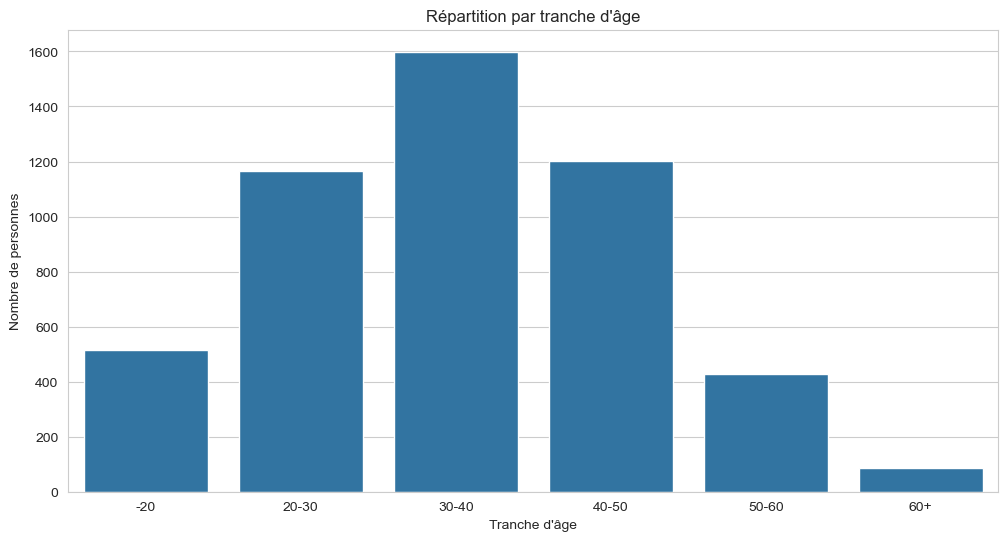

In [34]:

# Définir les tranches d'âges
bins = [0, 20, 30, 40, 50, 60, float('inf')]
labels = ["-20", "20-30", "30-40", "40-50", "50-60", "60+"]

df["Tranche_Age"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

# Afficher des clients par tranche d'âge
sns.countplot(x="Tranche_Age", data=df, order=labels)
plt.title("Répartition par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre de personnes")
plt.show()

  Tranche_Age  Total_Depense
2       30-40     1432556.91
3       40-50     1256062.96
1       20-30     1190575.66
0         -20      532538.95
4       50-60      431568.24
5         60+       72241.85


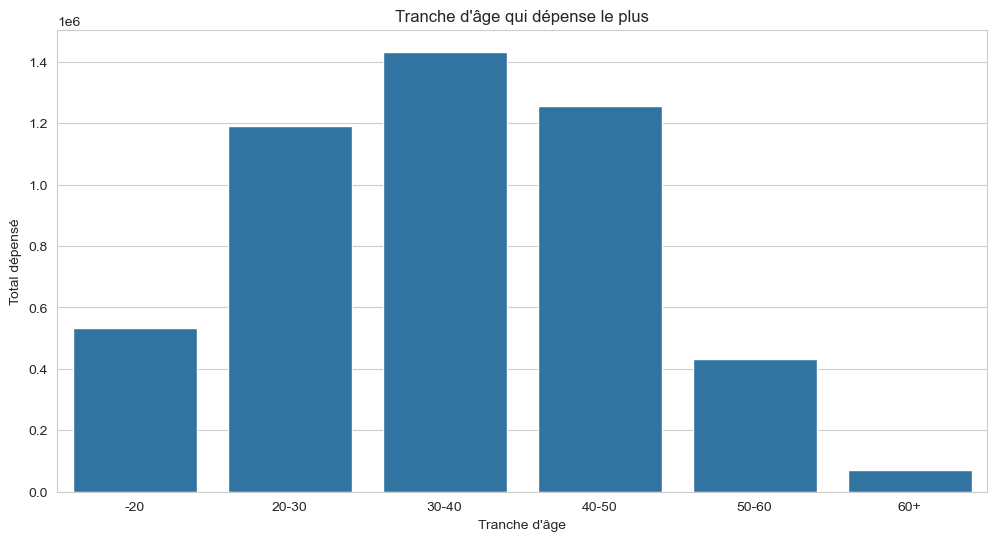

In [37]:
#Tranche d'âge qui dépense le plus
tableau = df.groupby("Tranche_Age")["Total_Amount"].sum().reset_index(name="Total_Depense")
tableau = tableau.sort_values("Total_Depense", ascending=False)

print(tableau)

# Étape 3 : Afficher le graphique
sns.barplot(x="Tranche_Age", y="Total_Depense", data=tableau)
plt.title("Tranche d'âge qui dépense le plus")
plt.xlabel("Tranche d'âge")
plt.ylabel("Total dépensé")
plt.show()

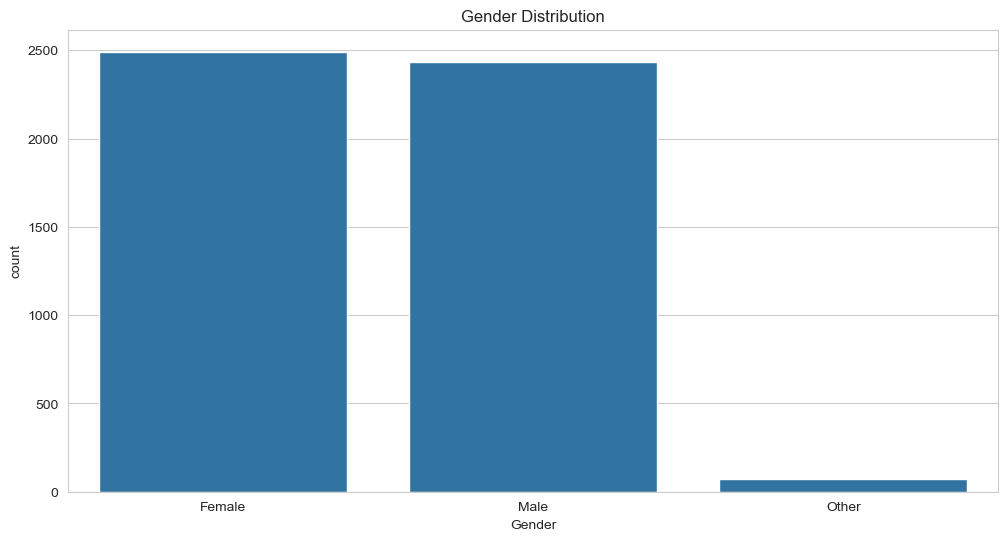

In [38]:
# Analyse des clients : identifier le genre dominant parmi les acheteurs
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

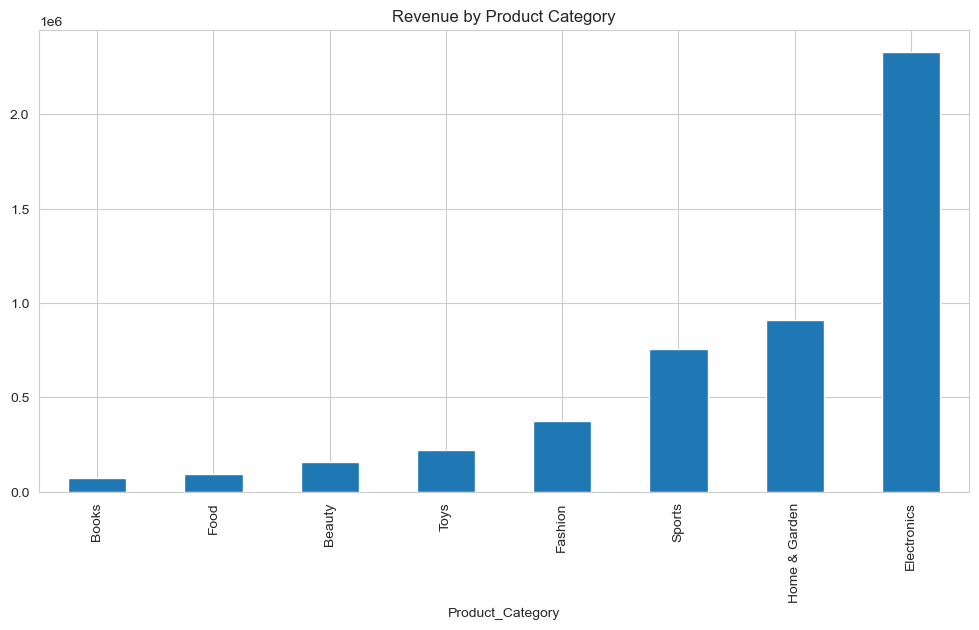

In [11]:
#revenu en fonction de la categorie du produit
sales_category = df.groupby("Product_Category")["Total_Amount"].sum()

sales_category.sort_values().plot(kind="bar")
plt.title("Revenue by Product Category")
plt.show()

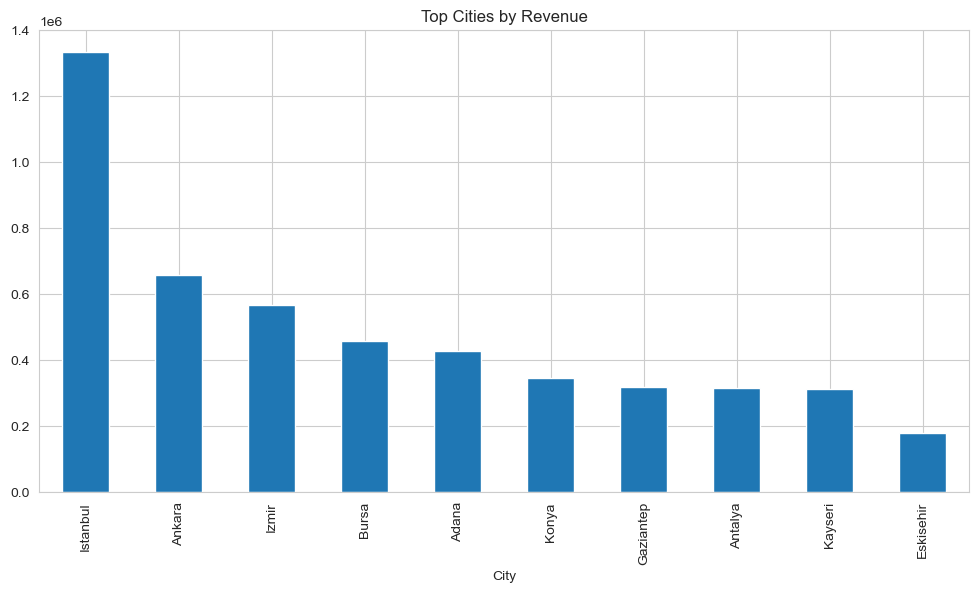

In [12]:
#Top 10 des villes qui font le plus de chiffres
sales_city = df.groupby("City")["Total_Amount"].sum().sort_values(ascending=False)

sales_city.head(10).plot(kind="bar")
plt.title("Top Cities by Revenue")
plt.show()

In [13]:
# Type d'appareil utilisé
Device = df["Device_Type"].value_counts()

# Afficher
print(Device)

Device_Type
Mobile     2795
Desktop    1711
Tablet      494
Name: count, dtype: int64


In [40]:
# Corrélation entre durée de session et montant d'achat
# analyser si une durée de session plus longue entraîne une augmentation du montant d'achat
# afin d’optimiser l’engagement utilisateur et maximiser les revenus

# Statistiques descriptives des deux variables
print("\nSession_Duration_Minutes :")
print(df["Session_Duration_Minutes"].describe())

print("\nTotal_Amount :")
print(df["Total_Amount"].describe())

# Tableau groupé par tranches de durée
df["Tranche_Session"] = pd.cut(df["Session_Duration_Minutes"], 
                                bins=[0, 15, 30, 45, 60],
                                labels=["0-15 min", "15-30 min", "30-45 min", "45-60 min"])

tableau = df.groupby("Tranche_Session")["Total_Amount"].agg(
    Nombre_Achats="count",
    Montant_Moyen="mean",
    Montant_Total="sum"
).reset_index()

print("\nMontant d'achat par tranche de session :\n", tableau)


Session_Duration_Minutes :
count    5000.00000
mean       14.57340
std         8.66575
min         1.00000
25%         8.00000
50%        13.00000
75%        19.00000
max        73.00000
Name: Session_Duration_Minutes, dtype: float64

Total_Amount :
count     5000.000000
mean       983.108914
std       1898.978528
min          7.870000
25%        122.517500
50%        337.910000
75%        979.695000
max      22023.900000
Name: Total_Amount, dtype: float64

Montant d'achat par tranche de session :
   Tranche_Session  Nombre_Achats  Montant_Moyen  Montant_Total
0        0-15 min           3089     983.111386     3036831.07
1       15-30 min           1638     990.373547     1622231.87
2       30-45 min            242     951.587314      230284.13
3       45-60 min             29     814.434483       23618.60


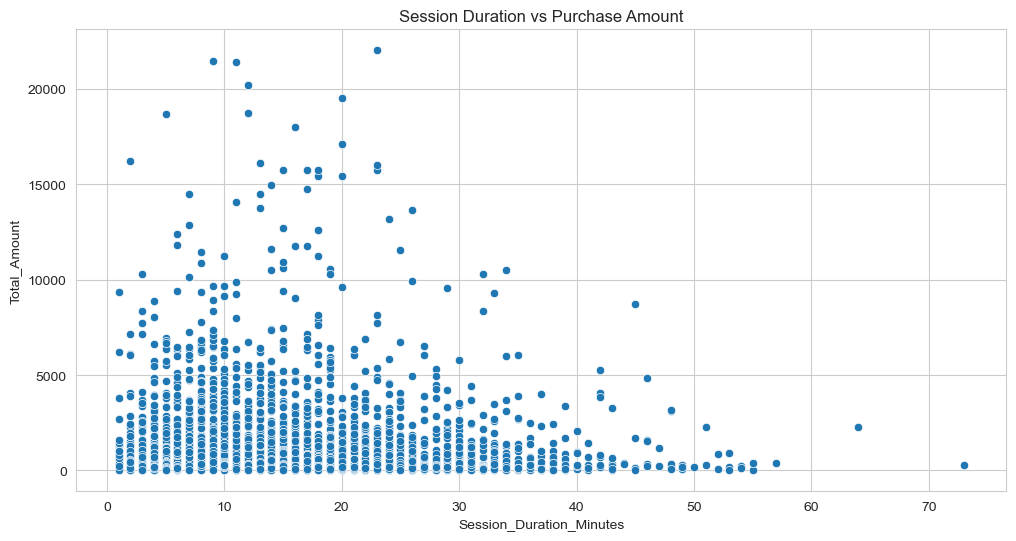

In [41]:
# Affichage du graphe durée de session contre Montant acheté
sns.scatterplot(x="Session_Duration_Minutes", y="Total_Amount", data=df)
plt.title("Session Duration vs Purchase Amount")
plt.show()

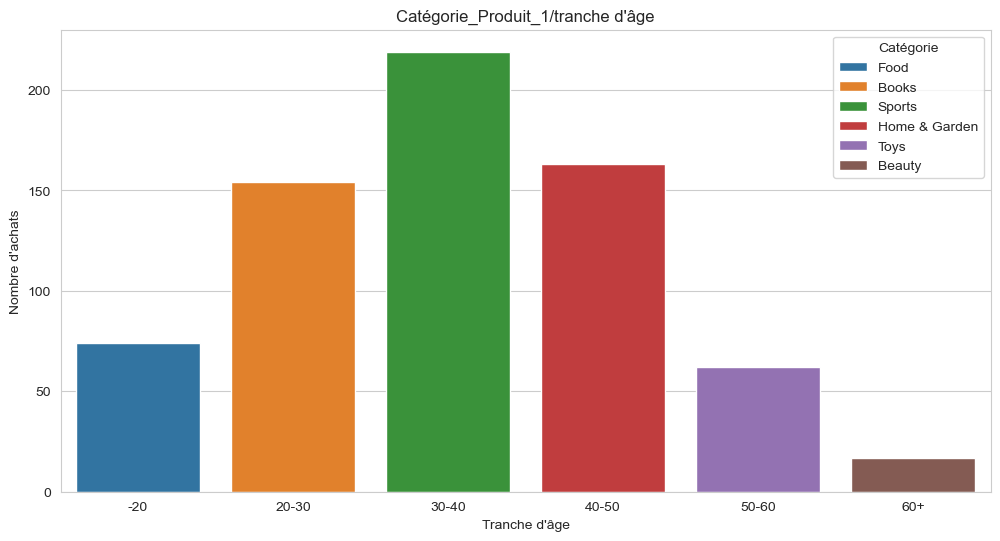

In [43]:
# Trouver la catégorie la plus achetée par tranche d'âge
tableau = df.groupby(["Tranche_Age", "Product_Category"]).size().reset_index(name="Nombre")
top = tableau.loc[tableau.groupby("Tranche_Age")["Nombre"].idxmax()]

# Afficher le graphique
sns.barplot(x="Tranche_Age", y="Nombre", hue="Product_Category", data=top)
plt.title("Catégorie_Produit_1/tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre d'achats")
plt.legend(title="Catégorie")
plt.show()

     Customer_ID  Total_Depense  Pages_Viewed
4222  CUST_04223          24.23          24.0
3231  CUST_03232        1712.13          22.0
2566  CUST_02567         130.35          20.0
1255  CUST_01256         425.12          19.0
1165  CUST_01166        1141.96          19.0
...          ...            ...           ...
1946  CUST_01947        1877.16           2.0
1978  CUST_01979          45.21           2.0
3011  CUST_03012         907.35           2.0
2384  CUST_02385          71.89           1.0
718   CUST_00719          68.42           1.0

[5000 rows x 3 columns]


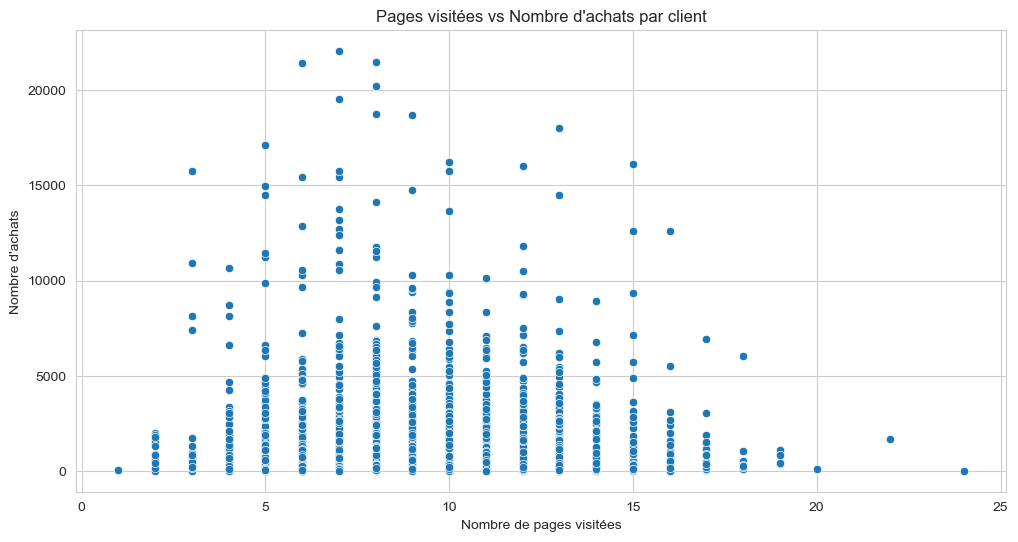

In [18]:
# Analyse du comportement client :
# étudier la relation entre le nombre de pages visitées et le montant d'achat
# pour déterminer si une navigation plus active entraîne une augmentation des dépenses

achats_par_client = df.groupby("Customer_ID")["Total_Amount"].sum().reset_index(name="Total_Depense")
pages_par_client = df.groupby("Customer_ID")["Pages_Viewed"].mean().reset_index()
tableau = achats_par_client.merge(pages_par_client, on="Customer_ID")

#Afficher le tableau
print(tableau.sort_values("Pages_Viewed", ascending=False))

#Afficher le graphique
sns.scatterplot(x="Pages_Viewed", y="Total_Depense", data=tableau)
plt.title("Pages visitées vs Nombre d'achats par client")
plt.xlabel("Nombre de pages visitées")
plt.ylabel("Nombre d'achats")
plt.show()

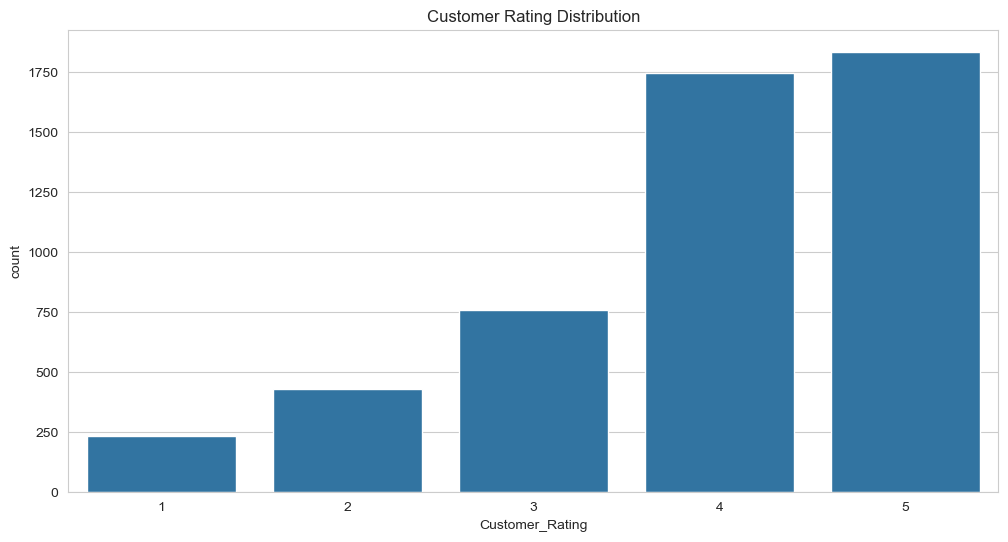

In [19]:
#Note des clients
sns.countplot(x="Customer_Rating", data=df)
plt.title("Customer Rating Distribution")
plt.show()

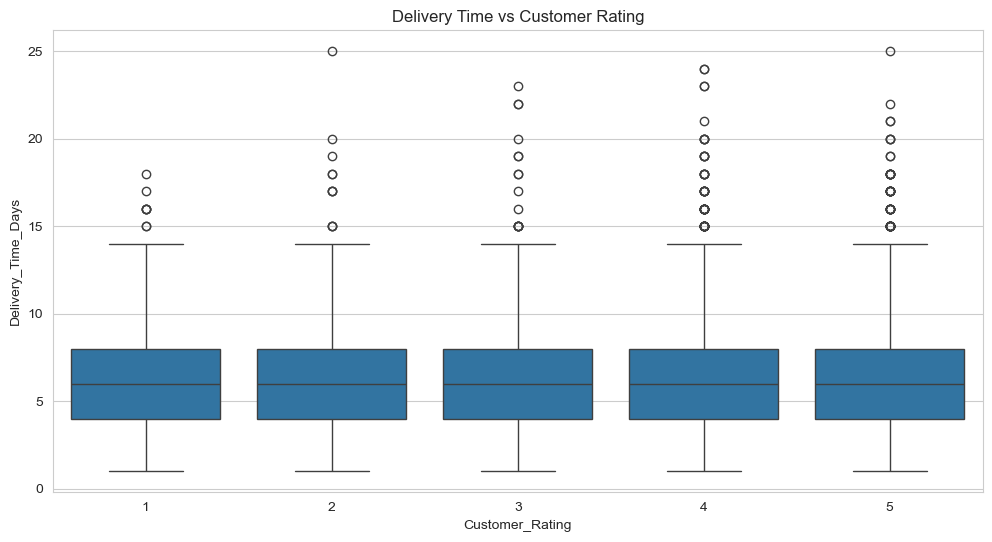

In [45]:
#Analyse de la satisfaction client :
# étudier la relation entre le délai de livraison et la note donnée par les clients
# pour déterminer si la rapidité de livraison influence la perception et l’évaluation du service
sns.boxplot(x="Customer_Rating", y="Delivery_Time_Days", data=df)
plt.title("Delivery Time vs Customer Rating")
plt.show()

In [24]:
# Répartition nouveaux vs clients récurrents
tableau = df["Is_Returning_Customer"].value_counts().reset_index()
tableau.columns = ["Type_Client", "Nombre"]
tableau["Type_Client"] = tableau["Type_Client"].map({True: "Client Récurrent", False: "Nouveau Client"})
tableau["Pourcentage(%)"] = (tableau["Nombre"] / tableau["Nombre"].sum() * 100).round(2)

print("Répartition nouveaux vs clients récurrents :\n", tableau)

Répartition nouveaux vs clients récurrents :
         Type_Client  Nombre  Pourcentage(%)
0  Client Récurrent    2990            59.8
1    Nouveau Client    2010            40.2


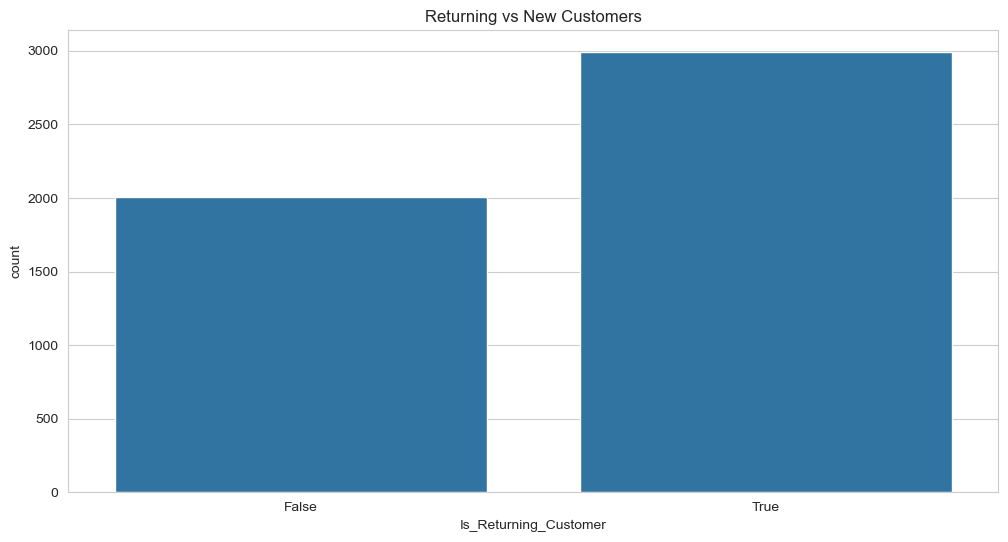

In [25]:
sns.countplot(x="Is_Returning_Customer", data=df)
plt.title("Returning vs New Customers")
plt.show()

In [46]:
# Dépense moyenne : récurrents vs nouveaux clients
print("1. Dépense moyenne par type de client :")
depense = df.groupby("Is_Returning_Customer")["Total_Amount"].agg(
    Nombre_Achats="count",
    Montant_Moyen="mean",
    Montant_Total="sum"
).round(2).reset_index()
depense["Is_Returning_Customer"] = depense["Is_Returning_Customer"].map({True: "Client Récurrent", False: "Nouveau Client"})
print(depense)


1. Dépense moyenne par type de client :
  Is_Returning_Customer  Nombre_Achats  Montant_Moyen  Montant_Total
0        Nouveau Client           2010         978.87     1967523.73
1      Client Récurrent           2990         985.96     2948020.84


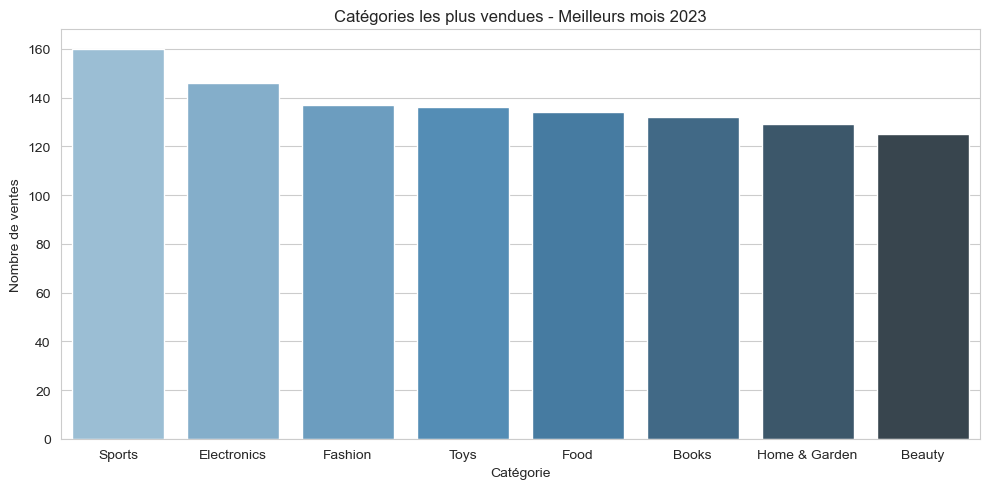

In [48]:
# Identifier les catégories les plus vendues durant les mois de forte performance
# afin d’optimiser les stocks, les promotions et les stratégies marketing saisonnières

df_2023 = df[df["Date"].dt.year == 2023]
df_2023["Mois"] = df_2023["Date"].dt.month
top_mois = df_2023.groupby("Mois").size().reset_index(name="Nombre_Ventes")
top_mois = top_mois.sort_values("Nombre_Ventes", ascending=False).head(3)


# Compter les ventes par catégorie sur ces mois
cat_top = df_top.groupby("Product_Category").size().reset_index(name="Nombre_Ventes")
cat_top = cat_top.sort_values("Nombre_Ventes", ascending=False)

# Graphique
plt.figure(figsize=(10, 5))
sns.barplot(x="Product_Category", y="Nombre_Ventes", data=cat_top, palette="Blues_d")
plt.title("Catégories les plus vendues - Meilleurs mois 2023")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de ventes")
plt.tight_layout()
plt.show()

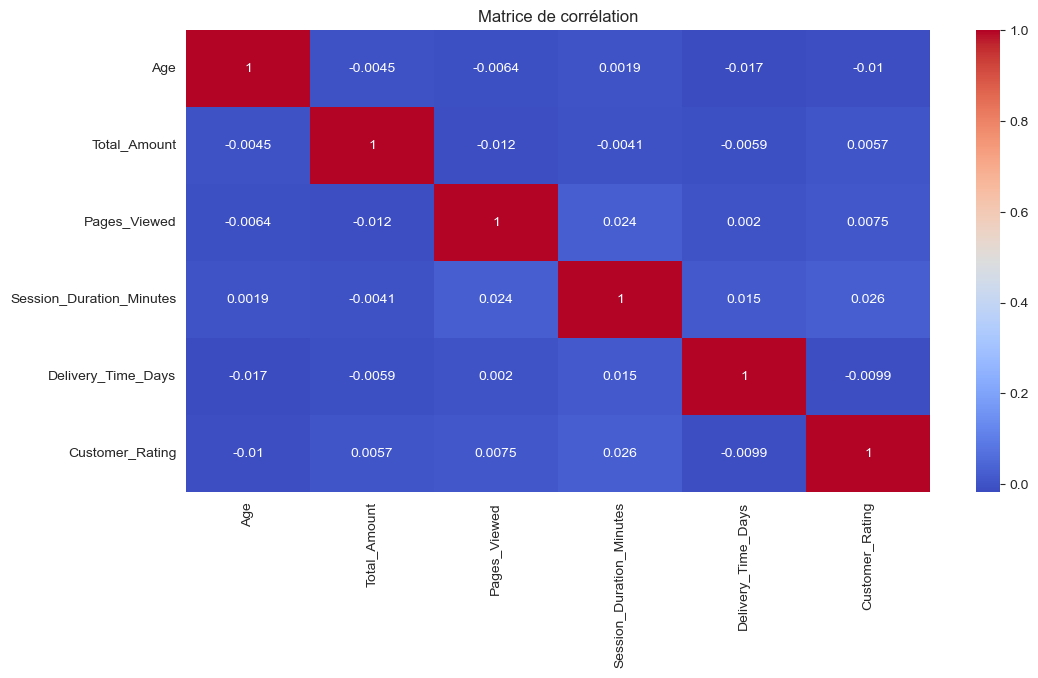

In [30]:
# Corrélation entre variables numériques
corr = df[["Age", "Total_Amount", "Pages_Viewed", 
           "Session_Duration_Minutes", "Delivery_Time_Days", 
           "Customer_Rating"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [49]:
# Modèle de classification : prédire la probabilité qu’un client attribue une bonne note
# en fonction de son comportement (montant, durée de session, pages vues, délai de livraison)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df["Bonne_Note"] = (df["Customer_Rating"] >= 4).astype(int)

# Choix des features
features = ["Age", "Total_Amount", "Pages_Viewed", 
            "Session_Duration_Minutes", "Delivery_Time_Days", "Quantity"]

X = df[features]
y = df["Bonne_Note"]

# Division en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement du modèle
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.30      0.05      0.09       284
           1       0.72      0.95      0.82       716

    accuracy                           0.70      1000
   macro avg       0.51      0.50      0.45      1000
weighted avg       0.60      0.70      0.61      1000

